In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

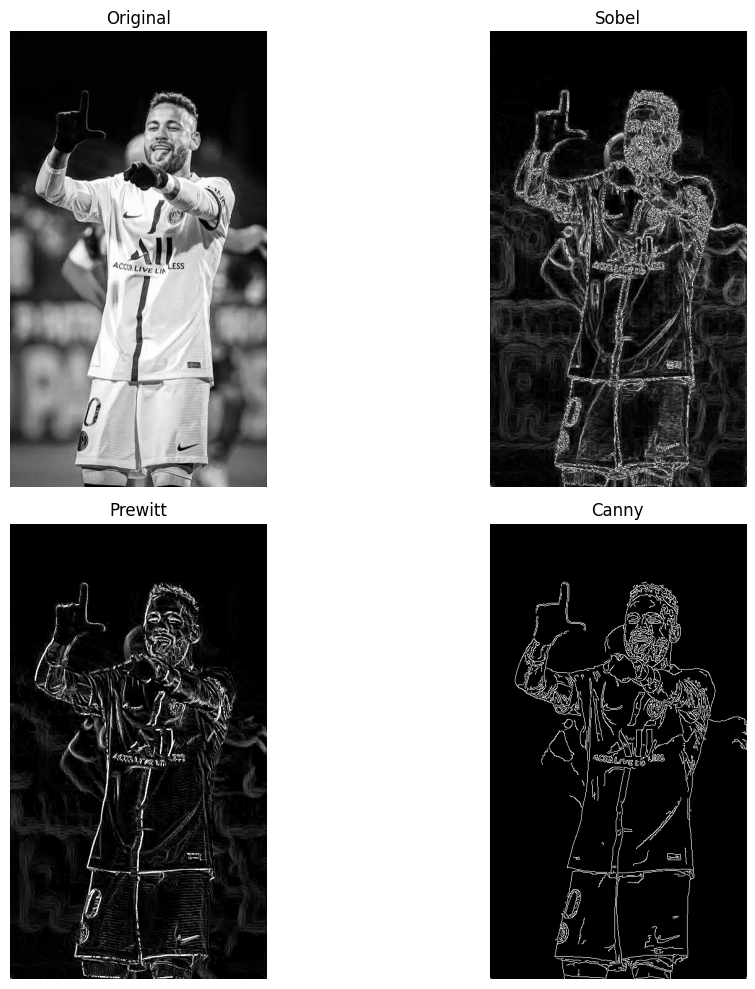

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


# DISPLAY
def show(original, sobel, prewitt, canny):
    plt.figure(figsize=(12, 10))

    # Original image
    plt.subplot(2, 2, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Original')
    plt.axis('off')

    # Sobel edge
    plt.subplot(2, 2, 2)
    plt.imshow(sobel, cmap='gray')
    plt.title('Sobel')
    plt.axis('off')

    # Prewitt edge
    plt.subplot(2, 2, 3)
    plt.imshow(prewitt, cmap='gray')
    plt.title('Prewitt')
    plt.axis('off')

    # Canny edge
    plt.subplot(2, 2, 4)
    plt.imshow(canny, cmap='gray')
    plt.title('Canny')
    plt.axis('off')

    plt.tight_layout()
    plt.show()


# Reading image
img = cv2.imread('neyyy.jpg', 0)

if img is None:
    print('Image not found')
else:

    # ---------------- SOBEL OPERATOR ----------------
    # Gradient in X and Y direction
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

    # Combine gradients
    sobel_combined = cv2.magnitude(sobelx, sobely)


    # ---------------- PREWITT OPERATOR ----------------
    kernelx = np.array([
        [1, 1, 1],
        [0, 0, 0],
        [-1, -1, -1]
    ])

    kernely = np.array([
        [-1, 0, 1],
        [-1, 0, 1],
        [-1, 0, 1]
    ])

    # Apply kernels
    prewittx = cv2.filter2D(img, -1, kernelx)
    prewitty = cv2.filter2D(img, -1, kernely)

    # Combine
    prewitt_combined = cv2.magnitude(
        prewittx.astype(np.float32),
        prewitty.astype(np.float32)
    )


    # ---------------- CANNY OPERATOR ----------------
    # Arguments: image, threshold1, threshold2
    canny_edges = cv2.Canny(img, 100, 200)


    # ---------------- DISPLAY ----------------
    show(
        img,
        np.uint8(np.absolute(sobel_combined)),
        np.uint8(np.absolute(prewitt_combined)),
        canny_edges
    )